In [15]:
import numpy as np , pandas as pd , matplotlib.pyplot as plt , seaborn as sns
import os ,sys

In [18]:
df = pd.read_csv('data/heart_disease_uci.csv')

In [11]:
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [19]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [12]:
df.shape

(920, 16)

In [14]:
df.columns.tolist()

['id',
 'age',
 'sex',
 'dataset',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

In [20]:
df.dtypes

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [22]:
df.describe

<bound method NDFrame.describe of       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  Fal

In [23]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [24]:
miss_pct = (df.isnull().sum()/len(df)) * 100
print(miss_pct)

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64


In [25]:
df.isnull().sum().sum()

np.int64(1759)

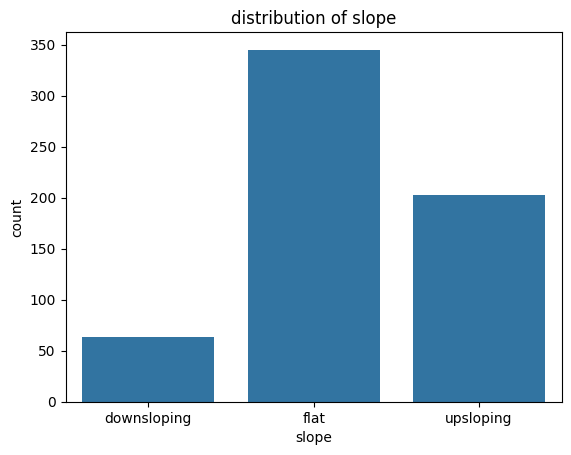

In [28]:
sns.countplot(x = df['slope'].dropna())
plt.title('distribution of slope')
plt.show()

In [35]:
df['slope'].isnull().sum()

np.int64(920)

In [43]:
print(df['slope'].value_counts())
print(df['slope'].isna().sum())
print(len(df))

Series([], Name: count, dtype: int64)
920
920


In [46]:
df = df.drop(columns = 'slope')

In [47]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'ca', 'thal', 'num'],
      dtype='object')

In [50]:
ca_column = df['ca']
ca_column.isnull().sum()

np.int64(611)

In [51]:
ca_column.value_counts()

ca
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

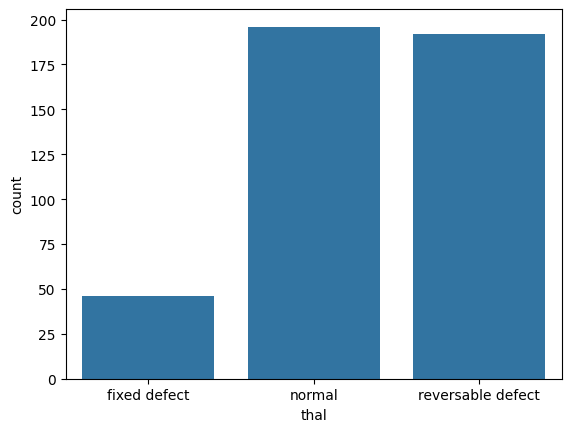

In [55]:
sns.countplot(data = df , x = 'thal' )
plt.show()

In [56]:
df['thal'].mode()[0]

'normal'

In [63]:
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect', nan], dtype=object)

In [64]:
thal_map = {
    'normal' : 1 ,
    'fixed defect' : 2 , 
    'reversable defect' : 3
}
df['thal'] = df['thal'].map(thal_map)

In [66]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors = 5)
df[['thal']] = imputer.fit_transform(df[['thal']])

In [67]:
df['thal'] = df['thal'].round().astype(int)
df['thal'] = df['thal'].clip(1, 3)

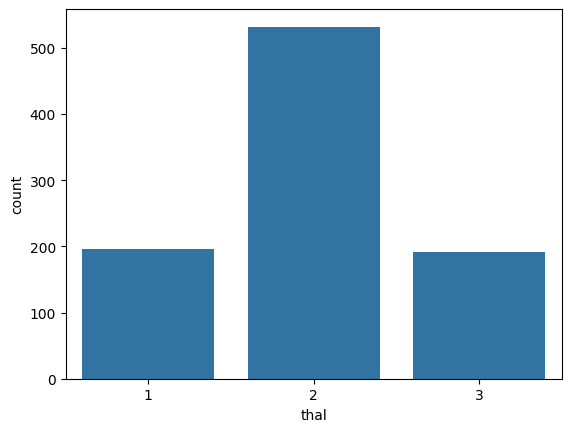

In [68]:
sns.countplot(data = df , x = 'thal')
plt.show()

In [71]:
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']: 
    df[col].fillna(df[col].median())
for col in ['fbs', 'restecg', 'exang']: 
    df[col].fillna(df[col].mode()[0])

In [73]:
imputer = KNNImputer(n_neighbors=5)
df[['ca']] = imputer.fit_transform(df[['ca']])
df['ca'] = df['ca'].round().astype(int)
df['ca'] = df['ca'].clip(0, 3)

In [74]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
ca          0
thal        0
num         0
dtype: int64

In [75]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [77]:
df['num'].value_counts(normalize = True)*100

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64

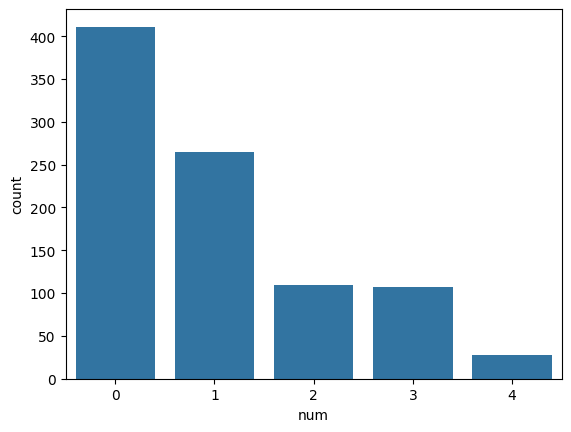

In [78]:
sns.countplot(data = df , x = 'num')
plt.show()

In [81]:
numerical_df = df.select_dtypes(include = ['int64' , 'float64'])

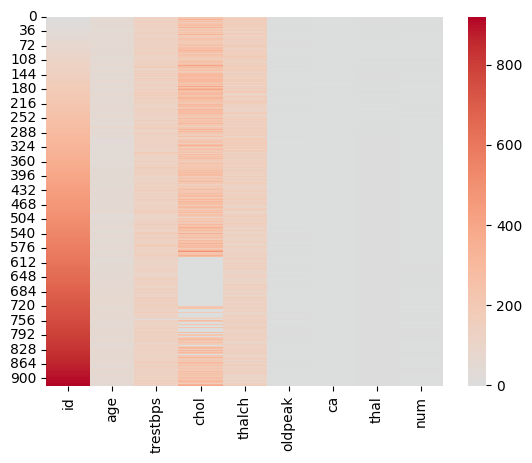

In [84]:
sns.heatmap(numerical_df , cmap = 'coolwarm' , center= 0)
plt.show()

In [85]:
df = df.drop(columns = 'id')

In [86]:
os.makedirs('data' , exist_ok = True)
df.to_csv('data/cleaned_heart_disease.csv' , index = False)